# Logistic Regression and Nearest Shrunken Centroid Modelling

This notebook evaluates interpretable baseline classifiers for neuroblastoma death-from-disease prediction using RNA-seq and microarray expression features.

The focus is on two model families:

- **Logistic Regression** as a regularized linear baseline.
- **Nearest Shrunken Centroid (NSC)** as a compact centroid-based classifier often used in high-dimensional gene expression settings.

Key outputs are saved to `figures/` and `results/`

## 0. Notebook setup

In [ ]:
# Loading required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import matthews_corrcoef, f1_score
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist
from sklearn.metrics import roc_auc_score
from scipy.spatial.distance import cdist


# Project-wide setup
# Creates folders used by the notebook when saving figures/tables.
from pathlib import Path
import warnings

PROJECT_ROOT = Path.cwd()
FIG_DIR = PROJECT_ROOT / ".."/ "figures"
RESULTS_DIR = PROJECT_ROOT / ".." / "results"
FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
warnings.filterwarnings("ignore")

def save_current_fig(filename: str, dpi: int = 300):
    """Save the active matplotlib figure to the figures/ directory."""
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

## 1. File paths and metadata loading

In [7]:
# Setting up directories and file names
fn_patient_info     = '../data/patientInfo.tsv'
fn_fpkm             = '../data/log2FPKM.tsv'             # RNA-Seq
fn_prop_intensities = '../data/allProbIntensities.tsv'   # Microarray

In [8]:
# metadata processing
# Load patient factors: 
df_patient_info = pd.read_csv(fn_patient_info, sep='\t').set_index('ID')

# Split into train and test based on missing endpoint values
df_patient_info_train = df_patient_info[df_patient_info['FactorValue..death.from.disease.'].notna()]
df_patient_info_test  = df_patient_info[df_patient_info['FactorValue..death.from.disease.'].isna()]

def clean_column_names(df):
   new_columns = []
   for col in df.columns:
       new_col = col.replace('FactorValue..', '').replace('..', '.').strip('.')
       new_columns.append(new_col)
   df.columns = new_columns
   df.columns.name = None 
   return df

df_patient_info = clean_column_names(df_patient_info.copy())
df_patient_info_train = clean_column_names(df_patient_info_train.copy())
df_patient_info_test = clean_column_names(df_patient_info_test.copy())

print("df_patient_info_train columns:")
display(df_patient_info_train.head())
print(" df_patient_info_test columns:")
display(df_patient_info_test.head())

# Define y_train and y_test using the patient info dataframes
# We cast to int as it is in 0.0 and 1.0.
# Assuming 1 = Death/Unfavorable and 0 = Survival/Favorable
y_train = df_patient_info_train['death.from.disease'].astype(int)

# Check the distribution to make sure it looks right
print("Class distribution in training set:")
print(y_train.value_counts())

df_patient_info_train columns:


,Sex,age.at.diagnosis,death.from.disease,high.risk,inss.stage,progression
ID,,,,,,
NB497,female,379,0.0,0.0,1,0.0
NB495,male,163,0.0,0.0,1,0.0
NB493,male,190,0.0,0.0,1,0.0
NB491,male,2326,0.0,1.0,4,1.0
NB489,female,865,0.0,1.0,4,0.0


 df_patient_info_test columns:


,Sex,age.at.diagnosis,death.from.disease,high.risk,inss.stage,progression
ID,,,,,,
NB498,female,530,NaN,NaN,NaN,NaN
NB496,male,132,NaN,NaN,NaN,NaN
NB494,male,56,NaN,NaN,NaN,NaN
NB492,male,947,NaN,NaN,NaN,NaN
NB490,female,1759,NaN,NaN,NaN,NaN


Class distribution in training set:
death.from.disease
0    198
1     51
Name: count, dtype: int64


## 2. Expression data loading

In [9]:
# load datasets

# Load RNA-Seq Data
print("Loading RNA-Seq Data...")
df_rna = pd.read_csv(fn_fpkm, sep='\t').rename({'00gene_id':'gene_id'}, axis=1)
df_rna = df_rna.set_index(['gene_id'])
df_rna.columns = [col.split('_')[0] for col in df_rna.columns] # Clean patient IDs
df_rna.columns.name = 'ID'
print("RNA-Seq Data loaded into DF")

# Load Microarray Data
print("Loading Microarray Data...")
df_micro = pd.read_csv(fn_prop_intensities, sep='\t').set_index(['Reporter.Identifier'])
df_micro.columns.name = 'ID'
print("Microarray Data loaded into DF")

Loading RNA-Seq Data...
RNA-Seq Data loaded into DF
Loading Microarray Data...
Microarray Data loaded into DF


## 3. Preprocessing helper functions

In [10]:
# define function for preprocessing:
# Pipeline Function
def preprocess(df_expr, train_meta, test_meta, dataset_name):
    """Align expression data to metadata, split train/test matrices, and scale features."""
    print(f"--- Processing {dataset_name} ---")

    # Drop NAs
    df_expr_numeric = df_expr.select_dtypes(include=[np.number]).dropna()

    # Apply Variance Filter (Top 25%)
    variances = df_expr_numeric.var(axis=1)
    var_threshold = variances.quantile(0.75)
    high_var_features = variances[variances > var_threshold].index
    print(f"Features remaining after variance filtering: {len(high_var_features)}")

    # Align IDs
    valid_train_ids = train_meta.index.intersection(df_expr_numeric.columns)
    valid_test_ids  = test_meta.index.intersection(df_expr_numeric.columns)

    # Subset and Transpose
    X_train_unscaled = df_expr_numeric.loc[high_var_features, valid_train_ids].T
    X_test_unscaled  = df_expr_numeric.loc[high_var_features, valid_test_ids].T

    # Scale Data
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_unscaled), 
        index=X_train_unscaled.index, 
        columns=X_train_unscaled.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_unscaled), 
        index=X_test_unscaled.index, 
        columns=X_test_unscaled.columns
    )

    # Also return the properly aligned target labels
    y_train = train_meta.loc[valid_train_ids, 'death.from.disease'].astype(int)

    print(f"{dataset_name} X_train shape: {X_train_scaled.shape}")
    return X_train_scaled, X_test_scaled, y_train

## 4. Apply preprocessing to RNA-seq and microarray data

In [11]:
# Execute the preprocessing function on both datasets:
X_train_rna_scaled, X_test_rna_scaled, y_train_rna = preprocess(
    df_rna, df_patient_info_train, df_patient_info_test, "RNA-Seq"
)

print("\n")

X_train_micro_scaled, X_test_micro_scaled, y_train_micro = preprocess(
    df_micro, df_patient_info_train, df_patient_info_test, "Microarray"
)

--- Processing RNA-Seq ---
Features remaining after variance filtering: 5787
RNA-Seq X_train shape: (249, 5787)


--- Processing Microarray ---
Features remaining after variance filtering: 10823
Microarray X_train shape: (249, 10823)


## 5. Target-aware correlation filtering

In [12]:
# Target-Aware Smart Correlation Filter
def correlation_filter(X_train, y_train, threshold=0.90):
    """Remove highly correlated expression features while keeping the feature most associated with the target."""
    # 1. Calculate how much each feature correlates with the TARGET
    target_corr = X_train.apply(lambda x: x.corr(y_train)).abs()

    # 2. Calculate feature-to-feature correlation
    corr_matrix_abs = X_train.corr().abs()

    # 3. Select upper triangle
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

    features_to_drop = set()

    # 4. Duel highly correlated pairs
    for col in upper.columns:
        if col in features_to_drop:
            continue

        highly_correlated_with_col = upper.index[upper[col] > threshold].tolist()

        for row_feature in highly_correlated_with_col:
            # Compare which one is better at predicting y_train
            if target_corr[col] > target_corr[row_feature]:
                features_to_drop.add(row_feature)
            else:
                features_to_drop.add(col)

    drop_list = list(features_to_drop)
    print(f"Dropped {len(drop_list)} redundant features.")
    return drop_list


# RUNNING THE FILTER ON BOTH DATASETS


print("--- Running Target-Aware Filter on RNA-Seq ---")
rna_features_to_drop = correlation_filter(X_train_rna_scaled, y_train_rna, threshold=0.90)
X_train_rna = X_train_rna_scaled.drop(columns=rna_features_to_drop)
X_test_rna = X_test_rna_scaled.drop(columns=rna_features_to_drop)
print(f"Final RNA-Seq Shape: {X_train_rna.shape}\n")


print("--- Running Target-Aware Filter on Microarray ---")
micro_features_to_drop = correlation_filter(X_train_micro_scaled, y_train_micro, threshold=0.90)
X_train_micro = X_train_micro_scaled.drop(columns=micro_features_to_drop)
X_test_micro = X_test_micro_scaled.drop(columns=micro_features_to_drop)
print(f"Final Microarray Shape: {X_train_micro.shape}")

--- Running Target-Aware Filter on RNA-Seq ---
Dropped 904 redundant features.
Final RNA-Seq Shape: (249, 4883)

--- Running Target-Aware Filter on Microarray ---
Dropped 3884 redundant features.
Final Microarray Shape: (249, 6939)


## 6. Recursive feature elimination

In [ ]:
# Independent Feature Selection via RFE (recursive feature elimination)

# Configure a robust tree-based model to evaluate feature importance
rfe_estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Running RFE on RNA-Seq data...")
rfe_rna = RFE(estimator=rfe_estimator, n_features_to_select=20, step=10)
rfe_rna.fit(X_train_rna, y_train_rna)

# Extract final RNA-Seq features
rna_best_features = X_train_rna.columns[rfe_rna.support_].tolist()
X_train_rna_final = X_train_rna[rna_best_features]
X_test_rna_final  = X_test_rna[rna_best_features]
print(f"Selected {len(rna_best_features)} best features for RNA-Seq.")
print(f"Best features for RNA-seq: {rna_best_features}")


print("\nRunning RFE on Microarray data...") # This may take a few minutes
rfe_micro = RFE(estimator=rfe_estimator, n_features_to_select=20, step=10)
rfe_micro.fit(X_train_micro, y_train_micro)

# Extract final Microarray features
micro_best_features = X_train_micro.columns[rfe_micro.support_]
X_train_micro_final = X_train_micro[micro_best_features]
X_test_micro_final  = X_test_micro[micro_best_features]
print(f"Selected {len(micro_best_features)} best features for Microarray.")
print(f"Best features for microarray: {micro_best_features}")

Running RFE on RNA-Seq data...
Selected 20 best features for RNA-Seq.
Best features for RNA-seq: ['BEND4', 'BZW2', 'C1orf201', 'CCBE1', 'CCDC34', 'CCDC86', 'CDCA4', 'CES4A', 'CNIH4', 'DKC1', 'FAM5B', 'SHC3', 'SKP2', 'SLC22A4', 'TFRC', 'TNFRSF25', 'TOM1L2', 'UBE2S', 'VRK1', 'WFDC2']

Running RFE on Microarray data...
Selected 20 best features for Microarray.
Best features for microarray: Index([ 6113, 11530, 34675, 34358, 42528,  9022, 14867, 33288,  1805, 17380,
       10646, 26999, 35456, 19706, 22453, 28578, 19343, 41983, 35011, 31950],
      dtype='int64', name='Reporter.Identifier')


## 7. RNA-seq logistic regression tuning

In [ ]:
# CV strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid of C values
C_grid = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for C in C_grid:

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    auc_scores = cross_val_score(
        model,
        X_train_rna_final,
        y_train_rna,
        cv=cv,
        scoring="roc_auc"
    )

    results.append({
        "C": C,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

tuning_df = pd.DataFrame(results)
display(tuning_df)

,C,Mean_AUC,Std_AUC
0,0.001,0.900789,0.038679
1,0.010,0.901818,0.044056
2,0.100,0.895941,0.049668
3,1.000,0.877875,0.051742
4,10.000,0.867324,0.044895
5,100.000,0.867350,0.042698


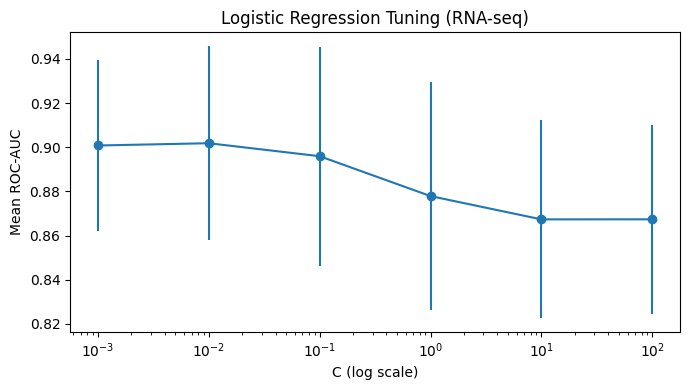

Saved figure: /Users/aman/Downloads/neuroblastoma_ml_portfolio_started/notebooks/../figures/../figures/04_log_reg_tuning.png


<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(7,4))

plt.errorbar(
    tuning_df["C"],
    tuning_df["Mean_AUC"],
    yerr=tuning_df["Std_AUC"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Mean ROC-AUC")
plt.title("Logistic Regression Tuning (RNA-seq)")
plt.tight_layout()
plt.show()

save_current_fig("../figures/04_log_reg_tuning.png")

In [23]:
best_C = 0.001

final_log_rna = LogisticRegression(
    penalty="l2",
    C=best_C,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

final_log_rna.fit(
    X_train_rna_final,
    y_train_rna
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


In [24]:
# AUC
auc_scores = cross_val_score(
    final_log_rna,
    X_train_rna_final,
    y_train_rna,
    cv=cv,
    scoring="roc_auc"
)

# CV predictions
y_pred_cv = cross_val_predict(
    final_log_rna,
    X_train_rna_final,
    y_train_rna,
    cv=cv,
    method="predict"
)

# Metrics
mcc = matthews_corrcoef(y_train_rna, y_pred_cv)
f1 = f1_score(y_train_rna, y_pred_cv)

print("Final Logistic RNA")
print("Mean AUC:", auc_scores.mean())
print("Std AUC :", auc_scores.std())
print("MCC     :", mcc)
print("F1      :", f1)

Final Logistic RNA
Mean AUC: 0.9007890442890443
Std AUC : 0.038678916611061466
MCC     : 0.558607210030161
F1      : 0.6357615894039735


## 8. RNA-seq NSC tuning

In [25]:
def evaluate_nsc_auc(X, y, shrink_threshold=0.5):

    # Convert to NumPy so row indexing works cleanly
    X = np.asarray(X)
    y = np.asarray(y)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):

        X_train_fold = X[train_idx]
        X_val_fold   = X[val_idx]

        y_train_fold = y[train_idx]
        y_val_fold   = y[val_idx]

        model = NearestCentroid(
            shrink_threshold=shrink_threshold
        )

        model.fit(X_train_fold, y_train_fold)

        dists = cdist(X_val_fold, model.centroids_)
        classes = model.classes_

        idx0 = np.where(classes == 0)[0][0]
        idx1 = np.where(classes == 1)[0][0]

        scores = dists[:, idx0] - dists[:, idx1]

        auc = roc_auc_score(y_val_fold, scores)
        auc_scores.append(auc)

    return np.array(auc_scores)

In [26]:
threshold_grid = [0.1, 0.2, 0.5, 1, 2, 3, 5]

results = []

for t in threshold_grid:
    auc_scores = evaluate_nsc_auc(
        X_train_rna_final,
        y_train_rna,
        shrink_threshold=t
    )

    results.append({
        "threshold": t,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

nsc_tuning_df = pd.DataFrame(results)
display(nsc_tuning_df)

,threshold,Mean_AUC,Std_AUC
0,0.1,0.903927,0.027053
1,0.2,0.903927,0.027053
2,0.5,0.904427,0.027775
3,1.0,0.902960,0.027731
4,2.0,0.897994,0.026152
5,3.0,0.878218,0.021166
6,5.0,0.500000,0.000000


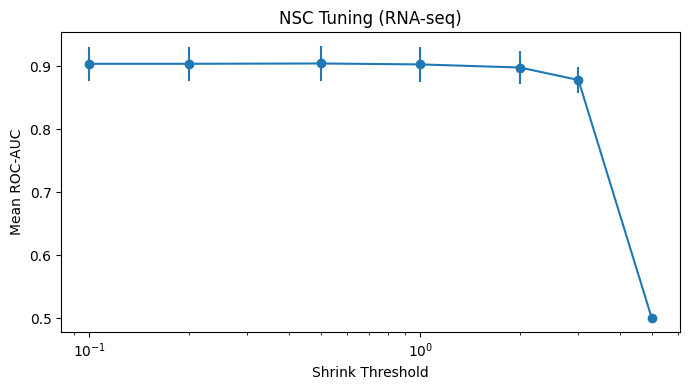

Saved figure: /Users/aman/Downloads/neuroblastoma_ml_portfolio_started/notebooks/../figures/../figures/05_nsc_tuning.png


<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(7,4))

plt.errorbar(
    nsc_tuning_df["threshold"],
    nsc_tuning_df["Mean_AUC"],
    yerr=nsc_tuning_df["Std_AUC"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Shrink Threshold")
plt.ylabel("Mean ROC-AUC")
plt.title("NSC Tuning (RNA-seq)")
plt.tight_layout()
plt.show()

save_current_fig("../figures/05_nsc_tuning.png")

In [29]:
# convert safely
X = np.asarray(X_train_rna_final)
y = np.asarray(y_train_rna)

# set best threshold from tuning
best_t = 0.2 # <-- CHANGE if your best was different

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# store outputs
scores_all = np.zeros(len(y))
preds_all  = np.zeros(len(y), dtype=int)

for train_idx, val_idx in cv.split(X, y):

    X_tr = X[train_idx]
    X_va = X[val_idx]

    y_tr = y[train_idx]

    # fit model
    model = NearestCentroid(
        shrink_threshold=best_t
    )

    model.fit(X_tr, y_tr)

    # distances
    dists = cdist(X_va, model.centroids_)
    classes = model.classes_

    idx0 = np.where(classes == 0)[0][0]
    idx1 = np.where(classes == 1)[0][0]

    # higher score = class 1
    scores = dists[:, idx0] - dists[:, idx1]

    scores_all[val_idx] = scores
    preds_all[val_idx] = (scores > 0).astype(int)

# final metrics
auc = roc_auc_score(y, scores_all)
mcc = matthews_corrcoef(y, preds_all)
f1  = f1_score(y, preds_all)

print("Final NSC RNA")
print("mean AUC :", round(auc,3))
print("MCC :", round(mcc,3))
print("F1  :", round(f1,3))

Final NSC RNA
mean AUC : 0.907
MCC : 0.597
F1  : 0.677


## 9. Microarray logistic regression tuning

In [30]:
warnings.filterwarnings("ignore")

X = X_train_micro_final
y = y_train_micro

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

C_grid = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for C in C_grid:

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    auc_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    results.append({
        "C": C,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

micro_log_tuning = pd.DataFrame(results)
display(micro_log_tuning)

,C,Mean_AUC,Std_AUC
0,0.001,0.892371,0.025426
1,0.010,0.911254,0.015976
2,0.100,0.919666,0.028990
3,1.000,0.873625,0.029425
4,10.000,0.846517,0.025068
5,100.000,0.839254,0.023256


In [31]:
best_C = 0.01 # <-- CHANGE if your best was different

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import matthews_corrcoef, f1_score

final_log_micro = LogisticRegression(
    penalty="l2",
    C=best_C,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# AUC
auc_scores = cross_val_score(
    final_log_micro,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

# CV predictions
y_pred_cv = cross_val_predict(
    final_log_micro,
    X,
    y,
    cv=cv,
    method="predict"
)

# metrics
mcc = matthews_corrcoef(y, y_pred_cv)
f1  = f1_score(y, y_pred_cv)

print("Final Logistic Microarray")
print("Mean AUC:", round(auc_scores.mean(),3))
print("Std AUC :", round(auc_scores.std(),3))
print("MCC     :", round(mcc,3))
print("F1      :", round(f1,3))

Final Logistic Microarray
Mean AUC: 0.911
Std AUC : 0.016
MCC     : 0.618
F1      : 0.686


## 10. Microarray NSC tuning

In [32]:
threshold_grid = [0.1, 0.2, 0.5, 1, 2, 3, 5]

results = []

for t in threshold_grid:

    auc_scores = evaluate_nsc_auc(
        X_train_micro_final,
        y_train_micro,
        shrink_threshold=t
    )

    results.append({
        "threshold": t,
        "Mean_AUC": auc_scores.mean(),
        "Std_AUC": auc_scores.std()
    })

nsc_micro_tuning = pd.DataFrame(results)
display(nsc_micro_tuning)

,threshold,Mean_AUC,Std_AUC
0,0.1,0.898033,0.024317
1,0.2,0.897054,0.024868
2,0.5,0.894121,0.024050
3,1.0,0.887697,0.024218
4,2.0,0.875348,0.023055
5,3.0,0.843430,0.031452
6,5.0,0.500000,0.000000


In [33]:
best_t = 0.1   # <-- CHANGE if your best was different


X = np.asarray(X_train_micro_final)
y = np.asarray(y_train_micro)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_all = np.zeros(len(y))
preds_all  = np.zeros(len(y), dtype=int)

for train_idx, val_idx in cv.split(X, y):

    X_tr = X[train_idx]
    X_va = X[val_idx]

    y_tr = y[train_idx]

    model = NearestCentroid(
        shrink_threshold=best_t
    )

    model.fit(X_tr, y_tr)

    dists = cdist(X_va, model.centroids_)
    classes = model.classes_

    idx0 = np.where(classes == 0)[0][0]
    idx1 = np.where(classes == 1)[0][0]

    scores = dists[:, idx0] - dists[:, idx1]

    scores_all[val_idx] = scores
    preds_all[val_idx] = (scores > 0).astype(int)

# Metrics
auc = roc_auc_score(y, scores_all)
mcc = matthews_corrcoef(y, preds_all)
f1  = f1_score(y, preds_all)

print("Final NSC Microarray")
print("Mean AUC:", round(auc,3))
print("MCC     :", round(mcc,3))
print("F1      :", round(f1,3))

Final NSC Microarray
Mean AUC: 0.899
MCC     : 0.573
F1      : 0.662


## 11. Cross-validated ROC curves and model comparison

In [39]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
import numpy as np

In [40]:
log_rna = LogisticRegression(
    penalty="l2",
    C=0.001,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

y_prob_log_rna = cross_val_predict(
    log_rna,
    X_train_rna_final,
    y_train_rna,
    cv=cv,
    method="predict_proba"
)[:,1]

In [41]:
log_micro = LogisticRegression(
    penalty="l2",
    C=0.01,   # replace if different best C
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

y_prob_log_micro = cross_val_predict(
    log_micro,
    X_train_micro_final,
    y_train_micro,
    cv=cv,
    method="predict_proba"
)[:,1]

In [42]:
def get_nsc_scores(X, y, threshold=1):

    X = np.asarray(X)
    y = np.asarray(y)

    scores_all = np.zeros(len(y))

    for train_idx, val_idx in cv.split(X, y):

        X_tr = X[train_idx]
        X_va = X[val_idx]
        y_tr = y[train_idx]

        model = NearestCentroid(
            shrink_threshold=threshold
        )
        model.fit(X_tr, y_tr)

        dists = cdist(X_va, model.centroids_)
        classes = model.classes_

        idx0 = np.where(classes==0)[0][0]
        idx1 = np.where(classes==1)[0][0]

        scores = dists[:,idx0] - dists[:,idx1]
        scores_all[val_idx] = scores

    return scores_all

In [43]:
# Replace thresholds if your tuned best values differ
y_score_nsc_rna   = get_nsc_scores(X_train_rna_final, y_train_rna, threshold=0.2)
y_score_nsc_micro = get_nsc_scores(X_train_micro_final, y_train_micro, threshold=0.1)

In [44]:
# Logistic RNA
fpr1, tpr1, _ = roc_curve(y_train_rna, y_prob_log_rna)
auc1 = auc(fpr1, tpr1)

# NSC RNA
fpr2, tpr2, _ = roc_curve(y_train_rna, y_score_nsc_rna)
auc2 = auc(fpr2, tpr2)

# Logistic Micro
fpr3, tpr3, _ = roc_curve(y_train_micro, y_prob_log_micro)
auc3 = auc(fpr3, tpr3)

# NSC Micro
fpr4, tpr4, _ = roc_curve(y_train_micro, y_score_nsc_micro)
auc4 = auc(fpr4, tpr4)

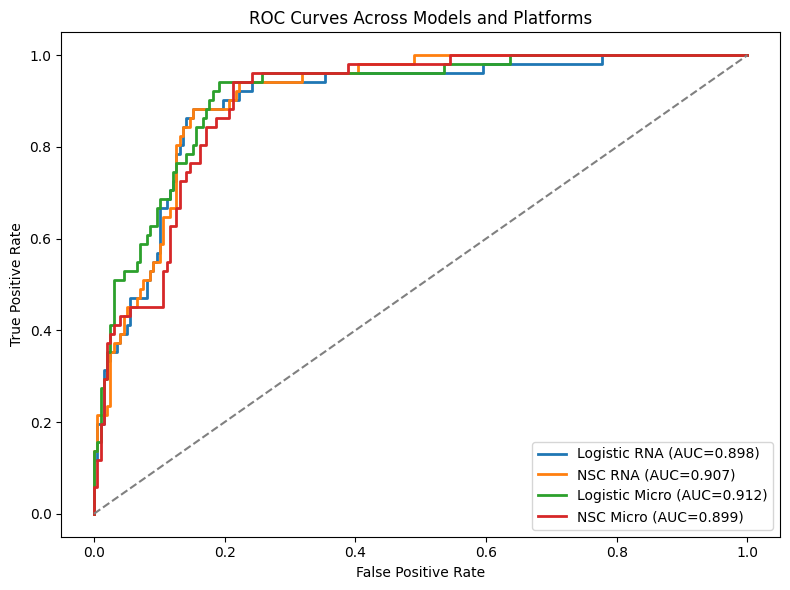

Saved figure: /Users/aman/Downloads/neuroblastoma_ml_portfolio_started/notebooks/../figures/../figures/06_ROC_Curves.png


<Figure size 640x480 with 0 Axes>

In [46]:
plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, linewidth=2,
         label=f"Logistic RNA (AUC={auc1:.3f})")

plt.plot(fpr2, tpr2, linewidth=2,
         label=f"NSC RNA (AUC={auc2:.3f})")

plt.plot(fpr3, tpr3, linewidth=2,
         label=f"Logistic Micro (AUC={auc3:.3f})")

plt.plot(fpr4, tpr4, linewidth=2,
         label=f"NSC Micro (AUC={auc4:.3f})")

# random classifier
plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Across Models and Platforms")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

save_current_fig("../figures/06_ROC_Curves.png")

In [47]:
from sklearn.base import clone


def predict_death_logistic(model, X_train, y_train, X_test, patient_ids, label):

    model = clone(model)
    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:,1]
    pred = (prob >= 0.5).astype(int)

    df = pd.DataFrame({
        "Patient_ID": patient_ids,
        f"{label}_Pred": pred,
        f"{label}_Prob": prob
    })

    print(f"\n{label}")
    print("No (0):", (pred==0).sum())
    print("Yes (1):", (pred==1).sum())

    return df

In [48]:
def predict_death_nsc(model, X_train, y_train, X_test, patient_ids, label):

    model = clone(model)
    model.fit(X_train, y_train)

    dists = cdist(X_test, model.centroids_)
    classes = model.classes_

    idx0 = np.where(classes==0)[0][0]
    idx1 = np.where(classes==1)[0][0]

    scores = dists[:,idx0] - dists[:,idx1]
    pred = (scores > 0).astype(int)

    df = pd.DataFrame({
        "Patient_ID": patient_ids,
        f"{label}_Pred": pred,
        f"{label}_Score": scores
    })

    print(f"\n{label}")
    print("No (0):", (pred==0).sum())
    print("Yes (1):", (pred==1).sum())

    return df

In [ ]:
log_model = LogisticRegression(
    penalty="l2",
    C=0.001,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

In [50]:
nsc_model = NearestCentroid(
    shrink_threshold=0.2
)

In [51]:
# labels + IDs
y_train = y_train_rna
patient_ids = df_patient_info_test.index

# Logistic RNA
pred_log_rna = predict_death_logistic(
    log_model,
    X_train_rna_final,
    y_train,
    X_test_rna_final,
    patient_ids,
    "Log_RNA"
)

# NSC RNA
pred_nsc_rna = predict_death_nsc(
    nsc_model,
    X_train_rna_final,
    y_train,
    X_test_rna_final,
    patient_ids,
    "NSC_RNA"
)

# Logistic Microarray
pred_log_micro = predict_death_logistic(
    log_model,
    X_train_micro_final,
    y_train,
    X_test_micro_final,
    patient_ids,
    "Log_Micro"
)

# NSC Microarray
pred_nsc_micro = predict_death_nsc(
    nsc_model,
    X_train_micro_final,
    y_train,
    X_test_micro_final,
    patient_ids,
    "NSC_Micro"
)


Log_RNA
No (0): 140
Yes (1): 109

NSC_RNA
No (0): 161
Yes (1): 88

Log_Micro
No (0): 135
Yes (1): 114

NSC_Micro
No (0): 166
Yes (1): 83


In [52]:
death_predictions = (
    pred_log_rna
    .merge(pred_nsc_rna, on="Patient_ID")
    .merge(pred_log_micro, on="Patient_ID")
    .merge(pred_nsc_micro, on="Patient_ID")
)

display(death_predictions.head())

,Patient_ID,Log_RNA_Pred,Log_RNA_Prob,NSC_RNA_Pred,NSC_RNA_Score,Log_Micro_Pred,Log_Micro_Prob,NSC_Micro_Pred,NSC_Micro_Score
0,NB498,1,0.504118,0,-1.506085,0,0.450292,0,-2.141426
1,NB496,1,0.517466,0,-1.076828,0,0.473281,0,-2.087371
2,NB494,0,0.397404,0,-3.980377,0,0.434008,0,-2.675287
3,NB492,1,0.648829,1,2.948762,1,0.606457,1,1.543423
4,NB490,1,0.741521,1,3.970969,1,0.689726,1,2.810186


In [53]:

thresholds = np.arange(0.1, 0.91, 0.05)

rows = []

for t in thresholds:
    pred = (y_prob_log_micro >= t).astype(int)

    rows.append({
        "threshold": t,
        "MCC": matthews_corrcoef(y_train_micro, pred),
        "F1": f1_score(y_train_micro, pred)
    })

thresh_df = pd.DataFrame(rows)
display(thresh_df.sort_values("MCC", ascending=False))

,threshold,MCC,F1
9,0.55,0.627113,0.696296
8,0.50,0.618189,0.685714
10,0.60,0.601268,0.682171
12,0.70,0.569361,0.660377
11,0.65,0.568078,0.661157
7,0.45,0.563712,0.640000
13,0.75,0.539165,0.604651
6,0.40,0.486376,0.573099
14,0.80,0.474921,0.506667
15,0.85,0.415001,0.411765


In [54]:
rows = []

for t in np.arange(-2, 2.05, 0.1):

    pred = (y_score_nsc_rna > t).astype(int)

    rows.append({
        "threshold": t,
        "MCC": matthews_corrcoef(y_train_rna, pred),
        "F1": f1_score(y_train_rna, pred)
    })

nsc_thresh_df = pd.DataFrame(rows)

display(nsc_thresh_df.sort_values("MCC", ascending=False).head(10))

,threshold,MCC,F1
23,0.3,0.636059,0.708661
24,0.4,0.636059,0.708661
26,0.6,0.635014,0.709677
29,0.9,0.634487,0.710744
28,0.8,0.634487,0.710744
22,0.2,0.629339,0.703125
25,0.5,0.628048,0.704000
27,0.7,0.620145,0.699187
30,1.0,0.619628,0.700855
21,0.1,0.616207,0.692308


In [55]:
# fit model
log_final = clone(log_model)
log_final.fit(X_train_micro_final, y_train_rna)

# probabilities
prob_log = log_final.predict_proba(X_test_micro_final)[:,1]

# optimized threshold
pred_log = (prob_log >= 0.55).astype(int)

# output
final_log_micro = pd.DataFrame({
    "Patient_ID": df_patient_info_test.index,
    "Pred_Log_Micro": pred_log,
    "Prob_Log_Micro": prob_log
})

print("Final Logistic Microarray")
print("No (0):", (pred_log==0).sum())
print("Yes (1):", (pred_log==1).sum())

display(final_log_micro.head())

Final Logistic Microarray
No (0): 178
Yes (1): 71


,Patient_ID,Pred_Log_Micro,Prob_Log_Micro
0,NB498,0,0.450292
1,NB496,0,0.473281
2,NB494,0,0.434008
3,NB492,1,0.606457
4,NB490,1,0.689726


In [56]:
# fit model
nsc_final = clone(nsc_model)
nsc_final.fit(X_train_rna_final, y_train_rna)

# distances
dists = cdist(X_test_rna_final, nsc_final.centroids_)
classes = nsc_final.classes_

idx0 = np.where(classes==0)[0][0]
idx1 = np.where(classes==1)[0][0]

scores = dists[:,idx0] - dists[:,idx1]

# optimized threshold
pred_nsc = (scores > 0.40).astype(int)

# output
final_nsc_rna = pd.DataFrame({
    "Patient_ID": df_patient_info_test.index,
    "Pred_NSC_RNA": pred_nsc,
    "Score_NSC_RNA": scores
})

print("Final NSC RNA")
print("No (0):", (pred_nsc==0).sum())
print("Yes (1):", (pred_nsc==1).sum())

display(final_nsc_rna.head())

Final NSC RNA
No (0): 168
Yes (1): 81


,Patient_ID,Pred_NSC_RNA,Score_NSC_RNA
0,NB498,0,-1.506085
1,NB496,0,-1.076828
2,NB494,0,-3.980377
3,NB492,1,2.948762
4,NB490,1,3.970969


In [57]:
results = []

In [58]:
log_rna = LogisticRegression(
    penalty="l2",
    C=best_C,   # your tuned value
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# AUC
auc_scores = cross_val_score(log_rna, X_train_rna_final, y_train_rna, cv=cv, scoring="roc_auc")

# predictions
y_pred = cross_val_predict(log_rna, X_train_rna_final, y_train_rna, cv=cv)

# metrics
results.append({
    "Model": "Logistic Regression",
    "Platform": "RNA-seq",
    "AUC": auc_scores.mean(),
    "MCC": matthews_corrcoef(y_train_rna, y_pred),
    "F1": f1_score(y_train_rna, y_pred)
})

In [59]:
auc = roc_auc_score(y_train_rna, y_score_nsc_rna)
mcc = matthews_corrcoef(y_train_rna, preds_all)
f1  = f1_score(y_train_rna, preds_all)

results.append({
    "Model": "NSC",
    "Platform": "RNA-seq",
    "AUC": auc,
    "MCC": mcc,
    "F1": f1
})

In [60]:
log_micro = LogisticRegression(
    penalty="l2",
    C=best_C,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

auc_scores = cross_val_score(log_micro, X_train_micro_final, y_train_micro, cv=cv, scoring="roc_auc")
y_pred = cross_val_predict(log_micro, X_train_micro_final, y_train_micro, cv=cv)

results.append({
    "Model": "Logistic Regression",
    "Platform": "Microarray",
    "AUC": auc_scores.mean(),
    "MCC": matthews_corrcoef(y_train_micro, y_pred),
    "F1": f1_score(y_train_micro, y_pred)
})

In [61]:
auc = roc_auc_score(y_train_micro, y_score_nsc_micro)
mcc = matthews_corrcoef(y_train_micro, preds_all)
f1  = f1_score(y_train_micro, preds_all)

results.append({
    "Model": "NSC",
    "Platform": "Microarray",
    "AUC": auc,
    "MCC": mcc,
    "F1": f1
})

In [62]:
final_results = pd.DataFrame(results)
final_results[["AUC","MCC","F1"]] = final_results[["AUC","MCC","F1"]].round(3)

display(final_results.sort_values("MCC", ascending=False))

,Model,Platform,AUC,MCC,F1
2,Logistic Regression,Microarray,0.911,0.618,0.686
0,Logistic Regression,RNA-seq,0.902,0.575,0.653
1,NSC,RNA-seq,0.907,0.573,0.662
3,NSC,Microarray,0.899,0.573,0.662


In [63]:
final_results_optimized = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Platform": "Microarray",
        "Optimized Threshold": 0.55,
        "MCC": 0.627,
        "F1": 0.696
    },
    {
        "Model": "NSC",
        "Platform": "RNA-seq",
        "Optimized Threshold": 0.35,
        "MCC": 0.636,
        "F1": 0.709
    }
])

display(final_results_optimized.sort_values("MCC", ascending=False))

,Model,Platform,Optimized Threshold,MCC,F1
1,NSC,RNA-seq,0.35,0.636,0.709
0,Logistic Regression,Microarray,0.55,0.627,0.696


In [64]:
binary_cols = {
    "death": "death.from.disease",
    "high_risk": "high.risk",
    "progression": "progression"
}

stage_col = "inss.stage"

In [66]:
final_predictions = pd.DataFrame({
    "Patient_ID": df_patient_info_test.index
})

In [67]:
for name, col in binary_cols.items():

    # training labels
    y_train = df_patient_info_train[col].astype(int).values

    # fit model
    model = clone(nsc_model)
    model.fit(X_train_rna_final, y_train)

    # compute distances
    dists = cdist(X_test_rna_final, model.centroids_)
    classes = model.classes_

    idx0 = np.where(classes == 0)[0][0]
    idx1 = np.where(classes == 1)[0][0]

    scores = dists[:, idx0] - dists[:, idx1]

    # threshold = 0.35 (optimized)
    preds = (scores > 0.35).astype(int)

    final_predictions[col] = preds

In [68]:
# training labels
y_stage = df_patient_info_train[stage_col].astype(str).values

# fit model
model = clone(nsc_model)
model.fit(X_train_rna_final, y_stage)

# predict
stage_preds = model.predict(X_test_rna_final)

final_predictions[stage_col] = stage_preds

In [69]:
display(final_predictions.head())
print("\nShape:", final_predictions.shape)

,Patient_ID,death.from.disease,high.risk,progression,inss.stage
0,NB498,0,0,0,1
1,NB496,0,0,0,3
2,NB494,0,0,0,2
3,NB492,1,1,1,4
4,NB490,1,1,1,4



Shape: (249, 5)


In [70]:
for col in final_predictions.columns:
    if col != "Patient_ID":
        print("\n", col)
        print(final_predictions[col].value_counts())


 death.from.disease
death.from.disease
0    167
1     82
Name: count, dtype: int64

 high.risk
high.risk
0    156
1     93
Name: count, dtype: int64

 progression
progression
0    150
1     99
Name: count, dtype: int64

 inss.stage
inss.stage
4     92
2     53
1     40
4S    34
3     30
Name: count, dtype: int64


In [76]:
final_predictions.to_csv("../results/nsc_rna_final_predictions.csv", index=False)

In [77]:
binary_cols = {
    "death": "death.from.disease",
    "high_risk": "high.risk",
    "progression": "progression"
}

stage_col = "inss.stage"

log_micro_predictions = pd.DataFrame({
    "Patient_ID": df_patient_info_test.index
})

In [78]:
for name, col in binary_cols.items():

    y_train = df_patient_info_train[col].astype(int).values

    model = clone(log_model)
    model.fit(X_train_micro_final, y_train)

    prob = model.predict_proba(X_test_micro_final)[:, 1]

    # optimized threshold
    preds = (prob >= 0.55).astype(int)

    log_micro_predictions[col] = preds
    log_micro_predictions[f"{col}_prob"] = prob

In [79]:
y_stage = df_patient_info_train[stage_col].astype(str).values

stage_model = clone(log_model)
stage_model.fit(X_train_micro_final, y_stage)

stage_preds = stage_model.predict(X_test_micro_final)

log_micro_predictions[stage_col] = stage_preds

In [81]:
display(log_micro_predictions.head())
print("Shape:", log_micro_predictions.shape)

for col in ["death.from.disease", "high.risk", "progression", "inss.stage"]:
    print("\n", col)
    print(log_micro_predictions[col].value_counts())

log_micro_predictions.to_csv("../results/microarray_final_predictions.csv", index=False)

,Patient_ID,death.from.disease,death.from.disease_prob,high.risk,high.risk_prob,progression,progression_prob,inss.stage
0,NB498,0,0.450292,0,0.468177,0,0.467550,1
1,NB496,0,0.473281,0,0.473520,0,0.482979,1
2,NB494,0,0.434008,0,0.430745,0,0.455147,1
3,NB492,1,0.606457,1,0.660932,1,0.591748,4
4,NB490,1,0.689726,1,0.703960,1,0.642966,4


Shape: (249, 8)

 death.from.disease
death.from.disease
0    178
1     71
Name: count, dtype: int64

 high.risk
high.risk
0    168
1     81
Name: count, dtype: int64

 progression
progression
0    186
1     63
Name: count, dtype: int64

 inss.stage
inss.stage
1     118
4     108
4S     14
3       5
2       4
Name: count, dtype: int64


In [82]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score,
    matthews_corrcoef, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

def compute_metrics(y_true, y_pred, y_score):

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        "Accuracy": acc,
        "Balanced Accuracy": bacc,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "MCC": mcc,
        "ROC-AUC": auc,
        "PR-AUC": pr_auc
    }

In [83]:

log_rna = LogisticRegression(
    penalty="l2",
    C=best_C,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

y_prob = cross_val_predict(log_rna, X_train_rna_final, y_train_rna, cv=cv, method="predict_proba")[:,1]
y_pred = (y_prob >= 0.5).astype(int)

metrics_log_rna = compute_metrics(y_train_rna, y_pred, y_prob)

In [84]:
y_score = y_score_nsc_rna
y_pred = (y_score > 0).astype(int)

metrics_nsc_rna = compute_metrics(y_train_rna, y_pred, y_score)

In [85]:
log_micro = LogisticRegression(
    penalty="l2",
    C=best_C,
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

y_prob = cross_val_predict(log_micro, X_train_micro_final, y_train_micro, cv=cv, method="predict_proba")[:,1]
y_pred = (y_prob >= 0.5).astype(int)

metrics_log_micro = compute_metrics(y_train_micro, y_pred, y_prob)

In [86]:
y_score = y_score_nsc_micro
y_pred = (y_score > 0).astype(int)

metrics_nsc_micro = compute_metrics(y_train_micro, y_pred, y_score)

In [87]:
final_metrics = pd.DataFrame([
    {"Model": "Logistic", "Platform": "RNA", **metrics_log_rna},
    {"Model": "NSC", "Platform": "RNA", **metrics_nsc_rna},
    {"Model": "Logistic", "Platform": "Microarray", **metrics_log_micro},
    {"Model": "NSC", "Platform": "Microarray", **metrics_nsc_micro}
])

display(final_metrics.round(3))

,Model,Platform,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,MCC,ROC-AUC,PR-AUC
0,Logistic,RNA,0.799,0.845,0.505,0.922,0.768,0.653,0.575,0.901,0.699
1,NSC,RNA,0.827,0.848,0.549,0.882,0.813,0.677,0.597,0.907,0.698
2,Logistic,Microarray,0.823,0.867,0.539,0.941,0.793,0.686,0.618,0.912,0.732
3,NSC,Microarray,0.823,0.831,0.544,0.843,0.818,0.662,0.573,0.899,0.670


In [88]:
def check_overfitting(model, X, y, name):

    # ---- TRAIN PERFORMANCE ----
    model.fit(X, y)

    # Probabilities (if available)
    if hasattr(model, "predict_proba"):
        y_prob_train = model.predict_proba(X)[:,1]
        y_pred_train = (y_prob_train >= 0.5).astype(int)
    else:
        # NSC case (use distance score)
        from scipy.spatial.distance import cdist

        dists = cdist(X, model.centroids_)
        classes = model.classes_

        idx0 = np.where(classes==0)[0][0]
        idx1 = np.where(classes==1)[0][0]

        y_score_train = dists[:,idx0] - dists[:,idx1]
        y_pred_train = (y_score_train > 0).astype(int)
        y_prob_train = y_score_train

    train_auc = roc_auc_score(y, y_prob_train)
    train_mcc = matthews_corrcoef(y, y_pred_train)

    # ---- CV PERFORMANCE ----
    if hasattr(model, "predict_proba"):
        y_prob_cv = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:,1]
        y_pred_cv = (y_prob_cv >= 0.5).astype(int)
    else:
        # use your precomputed NSC scores
        if "RNA" in name:
            y_prob_cv = y_score_nsc_rna
            y_pred_cv = (y_prob_cv > 0).astype(int)
        else:
            y_prob_cv = y_score_nsc_micro
            y_pred_cv = (y_prob_cv > 0).astype(int)

    cv_auc = roc_auc_score(y, y_prob_cv)
    cv_mcc = matthews_corrcoef(y, y_pred_cv)

    return {
        "Model": name,
        "Train AUC": train_auc,
        "CV AUC": cv_auc,
        "Train MCC": train_mcc,
        "CV MCC": cv_mcc
    }

In [89]:
results_overfit = []

# Logistic RNA
results_overfit.append(
    check_overfitting(log_model, X_train_rna_final, y_train_rna, "Logistic RNA")
)

# NSC RNA
results_overfit.append(
    check_overfitting(nsc_model, X_train_rna_final, y_train_rna, "NSC RNA")
)

# Logistic Micro
results_overfit.append(
    check_overfitting(log_model, X_train_micro_final, y_train_micro, "Logistic Micro")
)

# NSC Micro
results_overfit.append(
    check_overfitting(nsc_model, X_train_micro_final, y_train_micro, "NSC Micro")
)

overfit_df = pd.DataFrame(results_overfit).round(3)
display(overfit_df)

,Model,Train AUC,CV AUC,Train MCC,CV MCC
0,Logistic RNA,0.904,0.898,0.559,0.559
1,NSC RNA,0.895,0.890,0.603,0.603
2,Logistic Micro,0.903,0.893,0.584,0.579
3,NSC Micro,0.890,0.884,0.582,0.567


In [90]:
y_stage = df_patient_info_train["inss.stage"].astype(str).values

log_stage = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced"
)

y_pred_stage_log = cross_val_predict(
    log_stage,
    X_train_micro_final,
    y_stage,
    cv=cv
)

In [91]:
model = NearestCentroid(shrink_threshold=1)

y_pred_stage_nsc = cross_val_predict(
    model,
    X_train_rna_final,
    y_stage,
    cv=cv
)

In [92]:
def compute_multiclass_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    return {
        "Accuracy": acc,
        "Balanced Accuracy": bacc,
        "F1 (Macro)": f1_macro,
        "F1 (Weighted)": f1_weighted
    }

In [93]:
metrics_log_stage = compute_multiclass_metrics(y_stage, y_pred_stage_log)
metrics_nsc_stage = compute_multiclass_metrics(y_stage, y_pred_stage_nsc)

In [94]:
stage_results = pd.DataFrame([
    {"Model": "Logistic", "Platform": "Microarray", **metrics_log_stage},
    {"Model": "NSC", "Platform": "RNA", **metrics_nsc_stage}
])

display(stage_results.round(3))

,Model,Platform,Accuracy,Balanced Accuracy,F1 (Macro),F1 (Weighted)
0,Logistic,Microarray,0.410,0.369,0.358,0.422
1,NSC,RNA,0.482,0.381,0.391,0.481
